# Insurance dataset for POE


## Importing libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import statsmodels.api as sm

## Data collection and analysis of dataset


In [52]:
# loading data from csv file to pandas dataframe
# viewing data and seeing the amount of rows and columns in the dataset
insurance_df = pd.read_csv(r"C:\Users\admin\Documents\POE\insurance.csv")
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### Load and Inspect Data
We load the dataset to begin analysis.  
We use .dtypes, .info() and .describe() to understand the structure, data types, and basic statistics.  
This helps us see what cleaning needs to be done to the data.

In [53]:
# getting some information about the dataset
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [54]:
#checking the statistical measures of the dataset
insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [55]:
#checking the data types for each column
insurance_df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

### Check Missing Values
We check for missing values using .isnull().sum().  
Missing data can affect model accuracy, so we need to identify that all data is accurate and that if there are any issues, they are handled early on.

In [56]:
#checking for missing values
insurance_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Data analysis (EDA PROCESS)
I have created plots to understand the data better.  
Distributions to show how values are spread.  
Count plots show how categories are balanced against each other for category features.  
This also helps with spotting patterns and outliers in the data.

<Figure size 800x500 with 0 Axes>

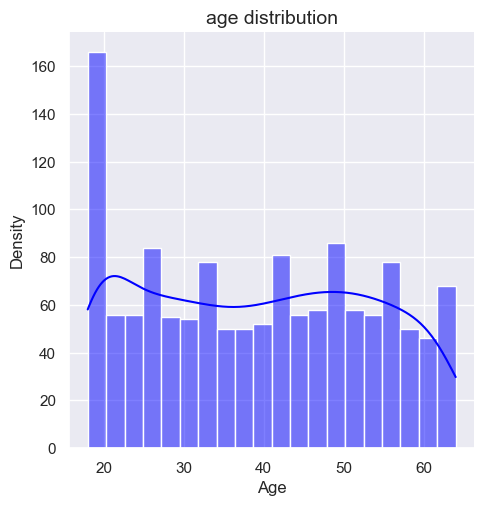

In [57]:
#Distribution of age value
sns.set()
plt.figure(figsize=(8,5))
sns.displot(insurance_df['age'], kde=True, color='blue', bins=20)
plt.title('age distribution', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

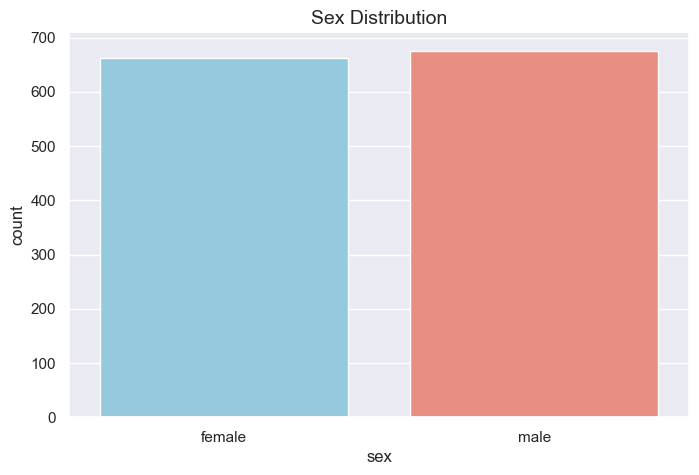

In [58]:
#gender column
plt.figure(figsize=(8,5))
my_colors = ['skyblue', 'salmon'] 
sns.countplot(x='sex', data=insurance_df, palette=my_colors, hue='sex', legend=False)
plt.title('Sex Distribution', fontsize=14)
plt.show()

In [13]:
insurance_df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

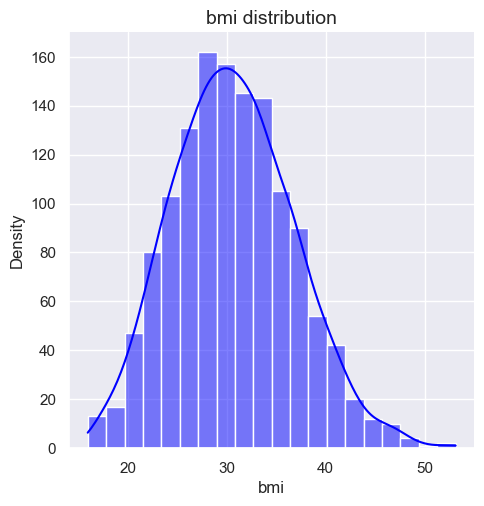

In [14]:
#bmi distribution
plt.figure(figsize=(8,5))
sns.displot(insurance_df['bmi'], kde=True, color='blue', bins=20)
plt.title('bmi distribution', fontsize=14)
plt.xlabel('bmi')
plt.ylabel('Density')
plt.show()

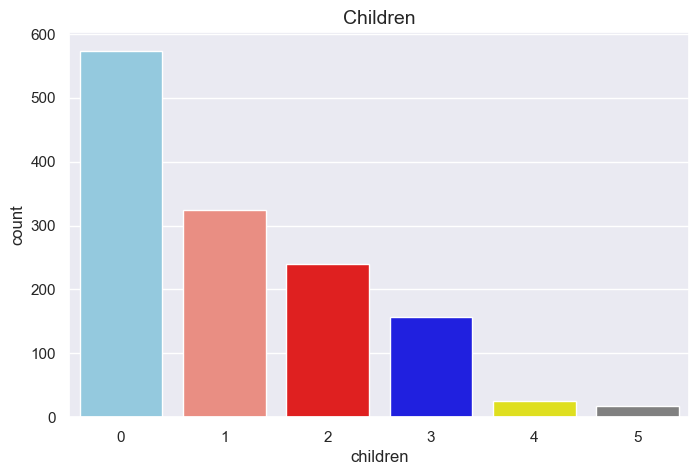

In [59]:
# children column 
plt.figure(figsize=(8,5))
my_colors = ['skyblue', 'salmon','red','blue','yellow','grey'] 
sns.countplot(x='children', data=insurance_df, palette=my_colors, hue='children', legend=False)
plt.title('Children', fontsize=14)
plt.show()

### Categorical features
.Sex

.Smoker

.Region

Since Linear Regression models cannot interpret text, these categorical features will undergo label encoding in the next phase so they are included in the model. Therefore, this will map each text label to a unique integer, allowing the regressor to calculate the coefficient of each category.

In [60]:
insurance_df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

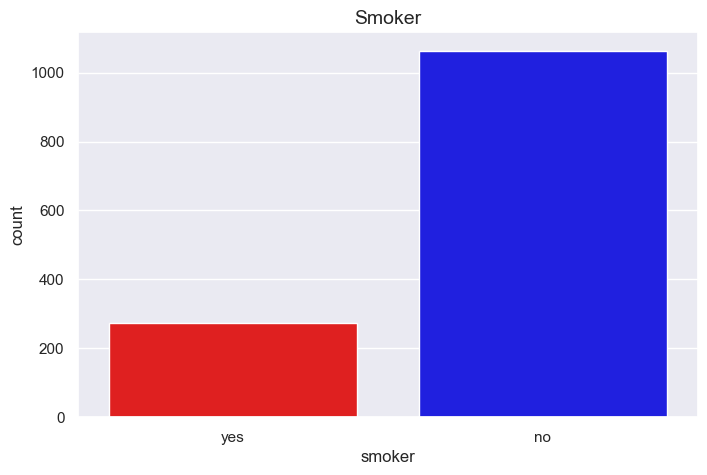

In [61]:
plt.figure(figsize=(8,5))
my_colors = ['red','blue'] 
sns.countplot(x='smoker', data=insurance_df, palette=my_colors, hue='smoker', legend=False)
plt.title('Smoker', fontsize=14)
plt.show()

In [62]:
insurance_df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

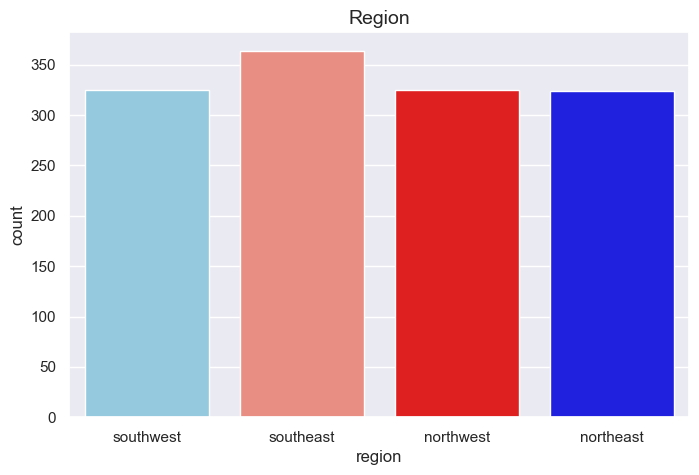

In [63]:
#region column
# children column 
plt.figure(figsize=(8,5))
my_colors = ['skyblue', 'salmon','red','blue'] 
sns.countplot(x='region', data=insurance_df, palette=my_colors, hue='region', legend=False)
plt.title('Region', fontsize=14)
plt.show()

In [64]:
insurance_df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

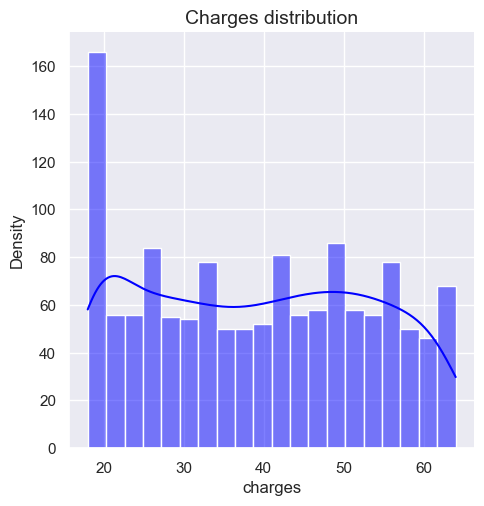

In [65]:
#distribution of charges value
plt.figure(figsize=(8,5))
sns.displot(insurance_df['age'], kde=True, color='blue', bins=20)
plt.title('Charges distribution', fontsize=14)
plt.xlabel('charges')
plt.ylabel('Density')
plt.show()

### Correlation Analysis
I used a heatmap to see relationships between variables.  
This helps identify which features strongly affect the target variable which are the charges.

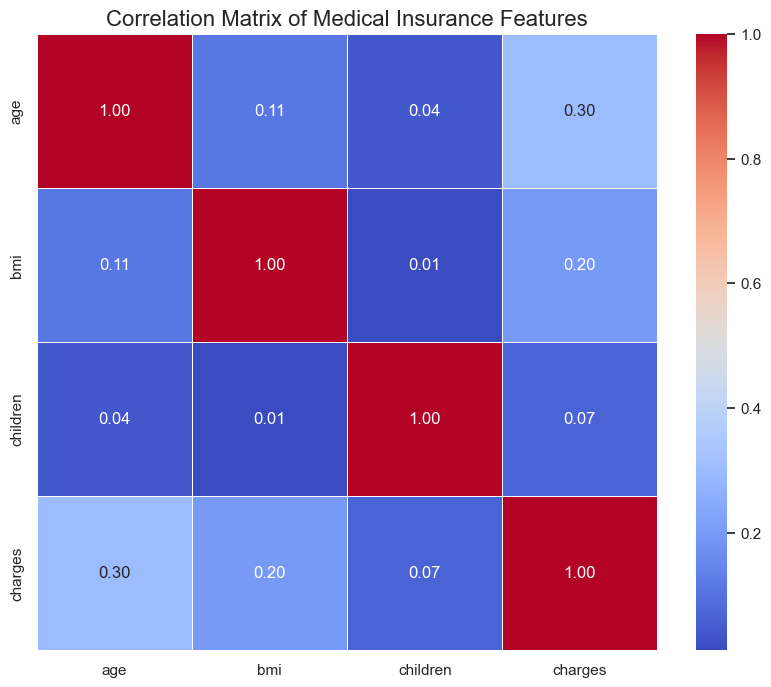

In [66]:
#Correlation Coefficient 
plt.figure(figsize=(10, 8))
sns.heatmap(insurance_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.rcParams['figure.figsize'] = (15,7)
plt.title('Correlation Matrix of Medical Insurance Features', fontsize=16)
plt.show()

## Data Pre-Processing
We convert categorical features into numbers using encoding.  
To allow the model to be able to work with the text data so it can be interpreted in the model.

#### Encoding the categorical features

In [67]:
pd.set_option('future.no_silent_downcasting', True)

# running the encoding for the categories
insurance_df['sex'] = insurance_df['sex'].map({'male': 0, 'female': 1})
insurance_df['smoker'] = insurance_df['smoker'].map({'yes': 0, 'no': 1})
insurance_df['region'] = insurance_df['region'].map({'southeast': 0, 'southwest': 1, 'northeast': 2, 'northwest': 3})

In [68]:
# checking to see if the encoding worked
print('--- New Data Types ---')
print(insurance_df.dtypes)

--- New Data Types ---
age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object


## Splitting the features and targets

In [69]:
X = insurance_df.drop(columns=['charges']) 
y = insurance_df['charges']

In [70]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       1
1      18    0  33.770         1       1       0
2      28    0  33.000         3       1       0
3      33    0  22.705         0       1       3
4      32    0  28.880         0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       3
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       0
1336   21    1  25.800         0       1       1
1337   61    1  29.070         0       0       3

[1338 rows x 6 columns]


In [71]:
print(y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


## splitting data into training data and testing data
We split the data into training and testing sets.  
Which the model learns from training data to test on new data to check performance.
We then go on to train the Linear Regression model using the training data.  
where this step allows the model to learn relationships between inputs and charges.

In [72]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print("Data split successfully!")

Data split successfully!


In [73]:
# to show the amount of values we have
print(X.shape, X_train.shape,X_test.shape)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(1338, 6) (1070, 6) (268, 6)


## P-value for foward and backward elimination 

I used the P-values to test how important each feature is in predicting the target variable.

Then in backward elimination, we start with all features and remove the one with the highest p-value.  
I wil repeat this process until all remaining features have p-values less than 0.05.

Then in forward selection, I add the features with the lowest p-value that which that will improves the model.

With these methods it helps select only the most important features, improving model accuracy and reducing any complexitis in the model.

In [74]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)

# Fit the OLS model
model = sm.OLS(y_train, X_train_sm).fit()

# Printing the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     507.7
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          6.06e-308
Time:                        14:11:19   Log-Likelihood:                -10846.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1063   BIC:                         2.174e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.109e+04   1220.517      9.088      0.0

In [75]:
X_train_final = X_train.drop(columns=['sex', 'region'])

#re-run of the OLS
X_train_sm_final = sm.add_constant(X_train_final)
model_final = sm.OLS(y_train, X_train_sm_final).fit()

#Print the final summary
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     762.1
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          1.26e-310
Time:                        14:11:26   Log-Likelihood:                -10847.
No. Observations:                1070   AIC:                         2.170e+04
Df Residuals:                    1065   BIC:                         2.173e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.154e+04   1117.090     10.327      0.0

## Model training

### Linear Regression

In [76]:
#loading the regression model
regressor = LinearRegression()

In [77]:
regressor.fit(X_train_final, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
#Prepare the Test Data
X_test_final = X_test.drop(columns=['sex', 'region'])

In [79]:
#prediction on the data
y_pred = regressor.predict(X_test_final)

### Evaluating the Model
We evaluate performance using metrics like R^2 and MAE to view just how accurate the model is.


In [80]:
#Calculate Accuracy Metrics
r2_test = metrics.r2_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)
print(f"Test R-squared: {r2_test:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")

Test R-squared: 0.7811
Mean Absolute Error (MAE): $4213.80


### Compare Actual vs Predicted
I will plot actual values against predicted values to see if the model is accurate.  
If the points of the charges are close to a straight line, then the model would be accurate.

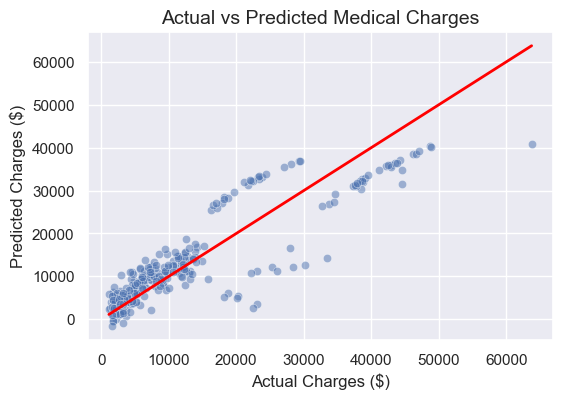

In [81]:
#Visualization: Actual vs. Predicted
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Actual vs Predicted Medical Charges', fontsize=14)
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.show()

In [82]:
#Calculating R-squared for Training Data
# We use the same regressor we already trained
y_train_pred = regressor.predict(X_train_final)
r2_train = metrics.r2_score(y_train, y_train_pred)

#Calculate R-squared for Test Data and comparison
r2_test = metrics.r2_score(y_test, y_pred)

print(f"Training R-squared: {r2_train:.4f}")
print(f"Test R-squared:     {r2_test:.4f}")
print(f"Difference:         {abs(r2_train - r2_test):.4f}")

Training R-squared: 0.7411
Test R-squared:     0.7811
Difference:         0.0400


## Model Performance Visualization: Actual vs. Predicted
To evaluate the effectiveness of the multiple linear regression model, we visualise the relationship between the actual insurance charges and the charges predicted by the model for both the Training and Test datasets.

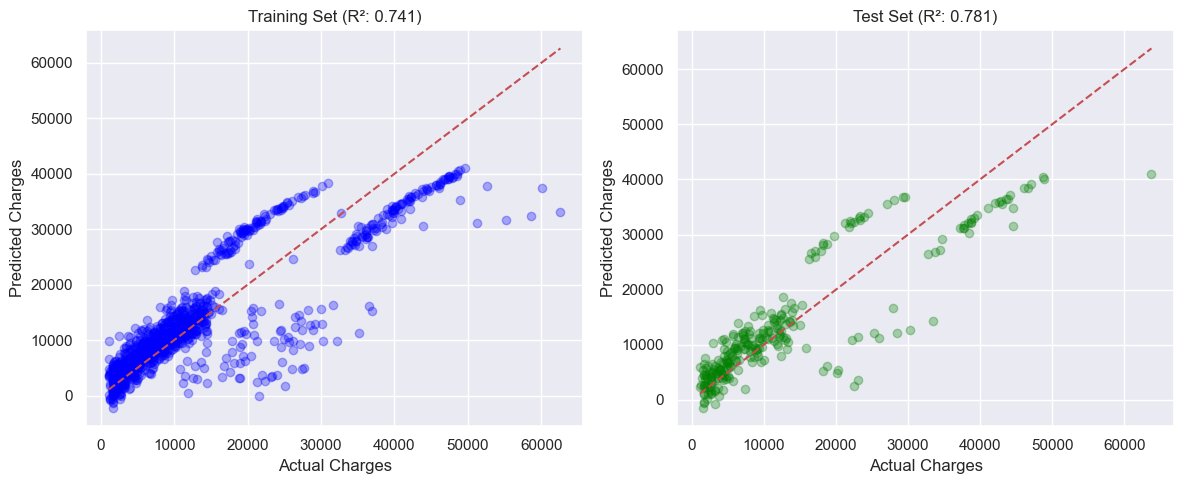

In [83]:
plt.figure(figsize=(12, 5))

# Plot Training Predictions
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.3, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.title(f'Training Set (R²: {r2_train:.3f})')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')

# Plot Test Predictions
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'Test Set (R²: {r2_test:.3f})')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')

plt.tight_layout()
plt.show()

## Building a predictive model
I then use the trained model to predict values on the test data, which 
will then show how well the model performs on unseen data.

In [84]:
def insurance_predict_system(age, sex, bmi, children, smoker, region):
    """
    Predictive System for Medical Insurance Charges.
    Automatically encodes categorical text to match the model's training.
    """

    # Creating a dictionary of the input data
    data = {
        'age': [age],
        'sex': [sex.lower()],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker.lower()],
        'region': [region.lower()]
    }

    # Convert to DataFrame
    input_df = pd.DataFrame(data)

    # Encoding
    input_df.replace({'sex': {'male': 0, 'female': 1}}, inplace=True)
    input_df.replace({'smoker': {'yes': 0, 'no': 1}}, inplace=True)
    input_df.replace({
        'region': {
            'southeast': 0,
            'southwest': 1,
            'northeast': 2,
            'northwest': 3
        }
    }, inplace=True)

    # Select final features
    final_features = input_df[['age', 'bmi', 'children', 'smoker']]

    # Prediction
    prediction = regressor.predict(final_features)

    return prediction[0]


# Call the function
final_result = insurance_predict_system(31, 'female', 25.74, 0, 'no', 'southeast')

print(final_result)
print(f"The predicted insurance cost is: ${final_result:,.2f}")

4282.563346753121
The predicted insurance cost is: $4,282.56
